# Credit Risk Prediction Model

# Import Libraries

# Credit Risk Prediction Model

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

# Data Loading and Initial Exploration

In [2]:
df = pd.read_csv("../data/german_credit_data.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [4]:
df.drop(columns=["Unnamed: 0"], inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [6]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.shape

(522, 10)

# Descriptive Statistics

In [7]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,522.0,NaN,NaN,NaN,34.888889,11.787918,19.0,26.0,31.5,41.0,75.0
Sex,522,2,male,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,522.0,NaN,NaN,NaN,1.875479,0.682811,0.0,2.0,2.0,2.0,3.0
Housing,522,3,own,349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,522,4,little,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,522,3,little,245,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,522.0,NaN,NaN,NaN,3278.745211,2929.155177,276.0,1297.5,2326.5,3971.25,18424.0
Duration,522.0,NaN,NaN,NaN,21.33908,12.474079,6.0,12.0,18.0,26.75,72.0
Purpose,522,8,car,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,522,2,good,291,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df["Risk"].value_counts()

Risk
good    291
bad     231
Name: count, dtype: int64

# Data Visualization

## Distribution of Numerical Features

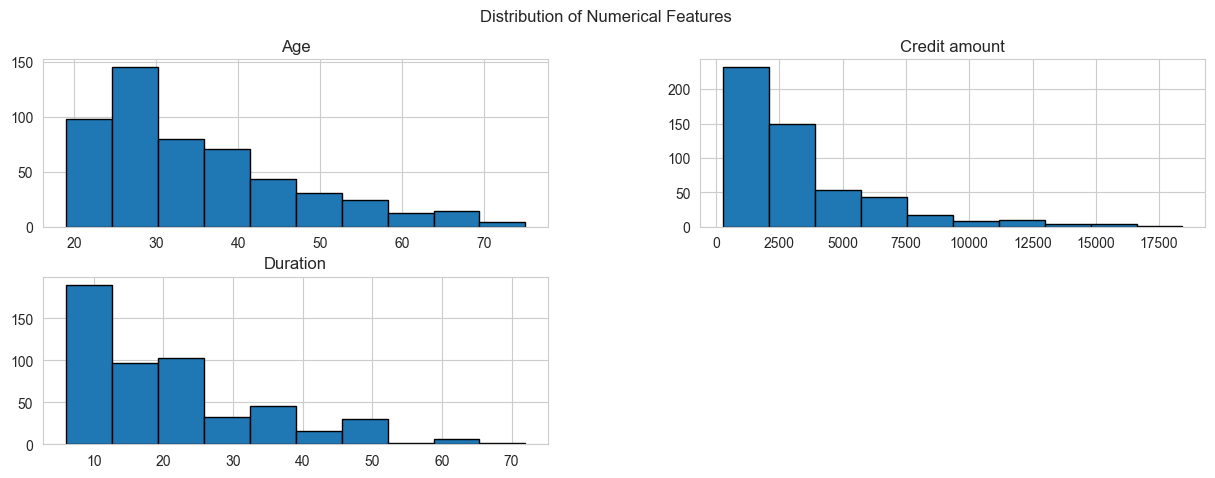

In [9]:
numerical_cols = ["Age", "Credit amount", "Duration"]

df[numerical_cols].hist(
    bins=10,
    figsize=(15,5),
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features")

plt.show()

## Outlier Detection in Numerical Features

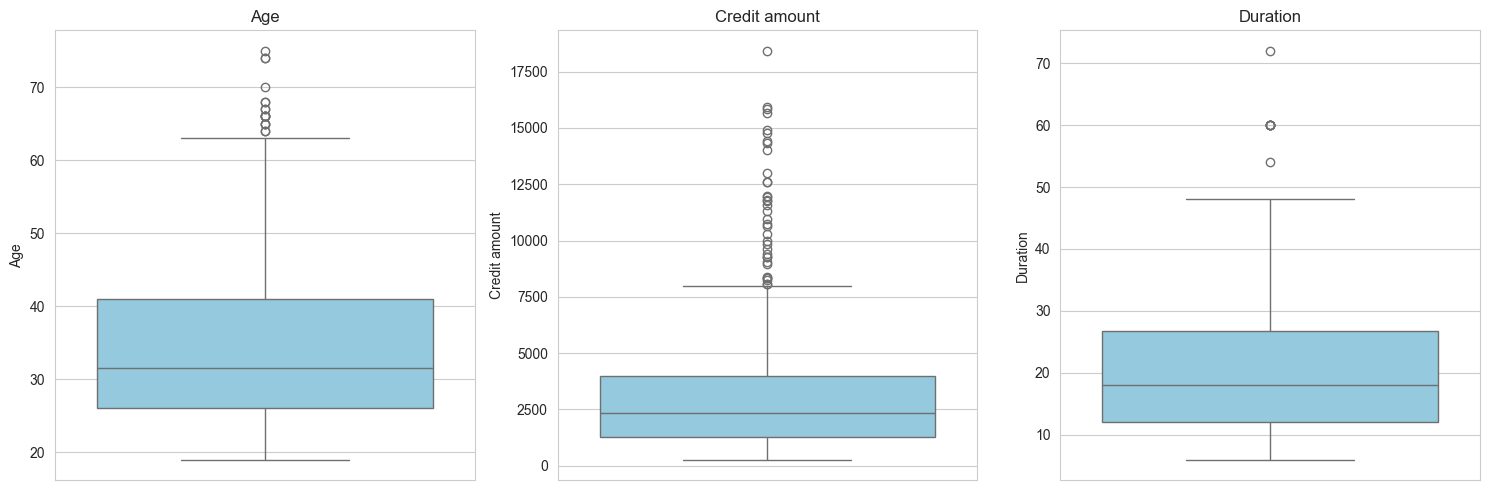

In [10]:
plt.figure(figsize=(15,5))

for i, col in enumerate(numerical_cols):

    plt.subplot(1,3,i+1)

    sns.boxplot(y=df[col], color="skyblue")

    plt.title(col)

plt.tight_layout()

plt.show()

## Distribution of Categorical Features

In [11]:
categorical_cols = [
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

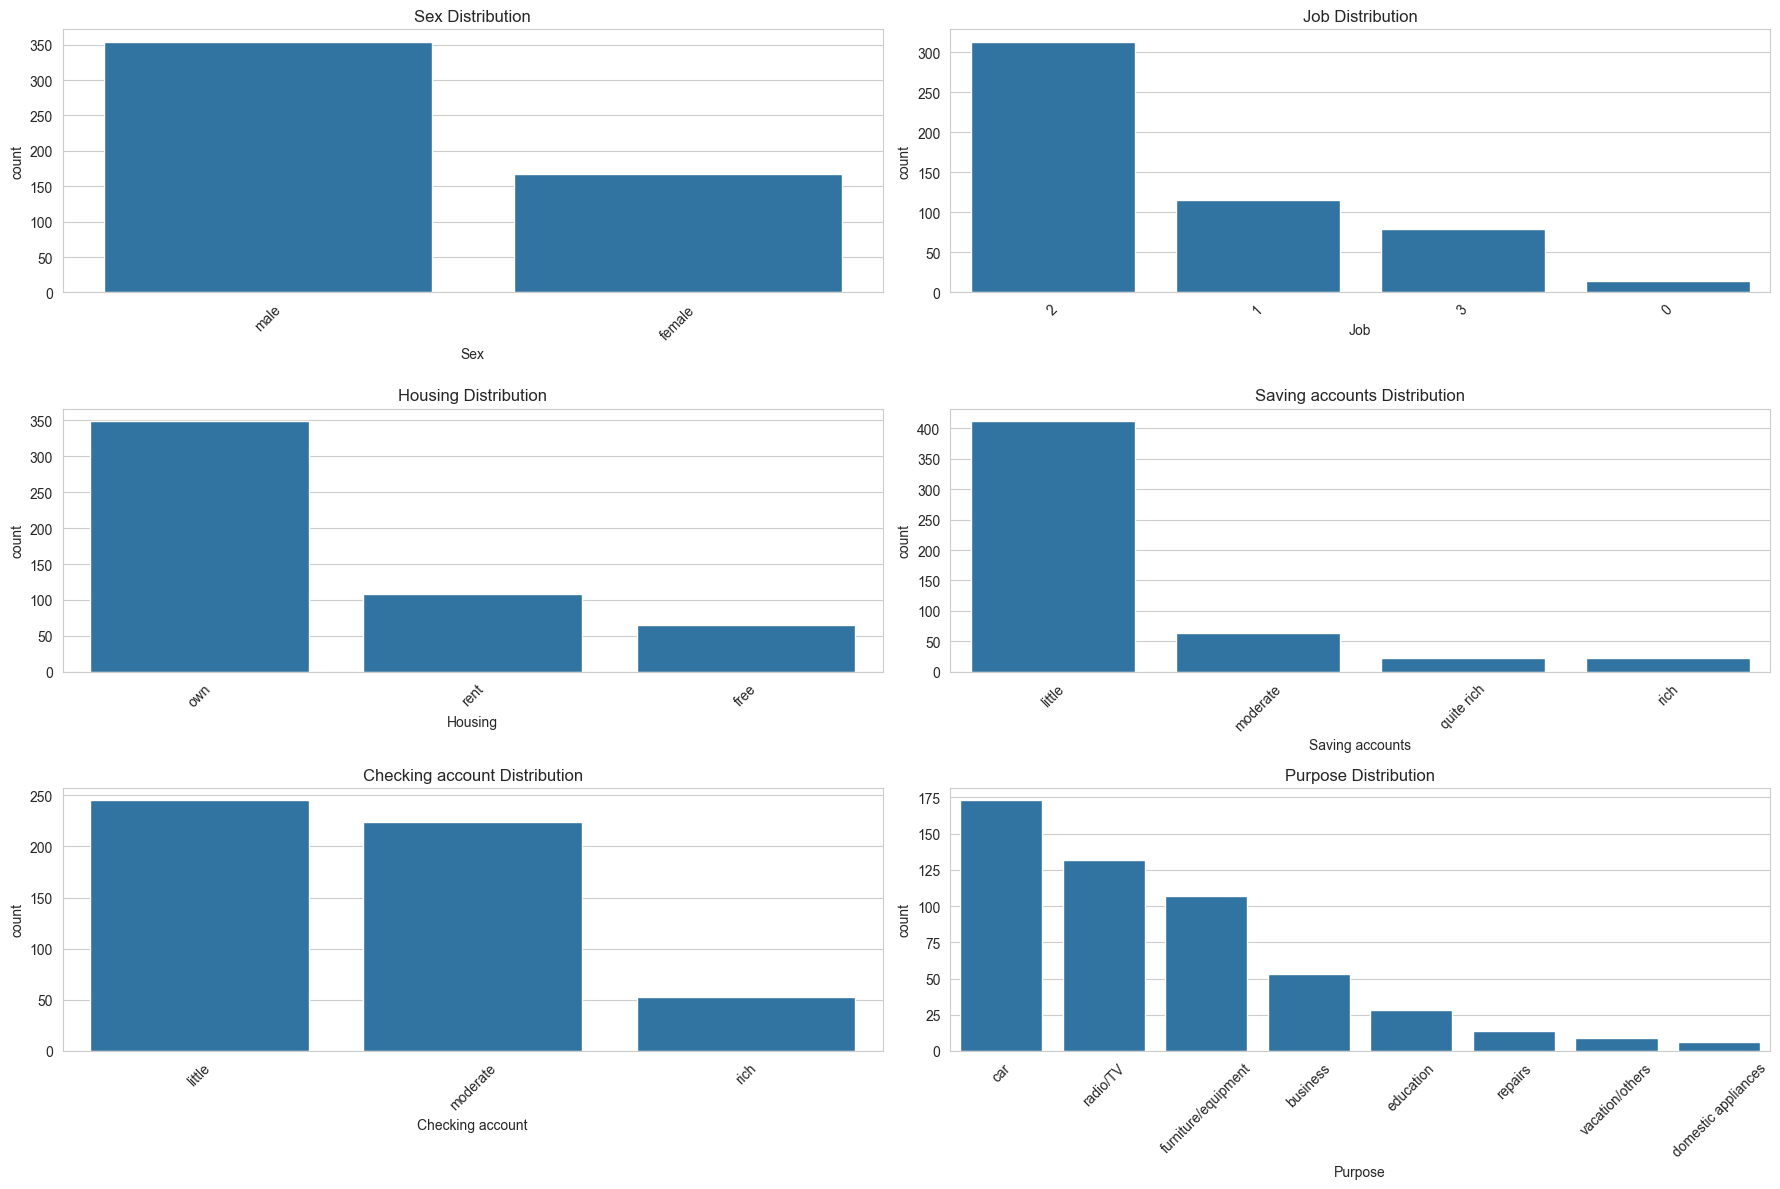

In [12]:
plt.figure(figsize=(18,12))

for i, col in enumerate(categorical_cols):

    plt.subplot(3,2,i+1)

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)

    plt.title(f"{col} Distribution")

plt.tight_layout()

plt.show()

## Correlation Analysis

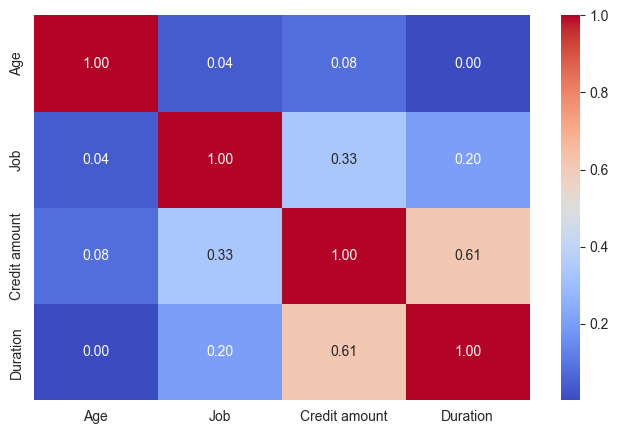

In [13]:
corr = df[["Age","Job","Credit amount","Duration"]].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.show()

## Feature Relationships with Target

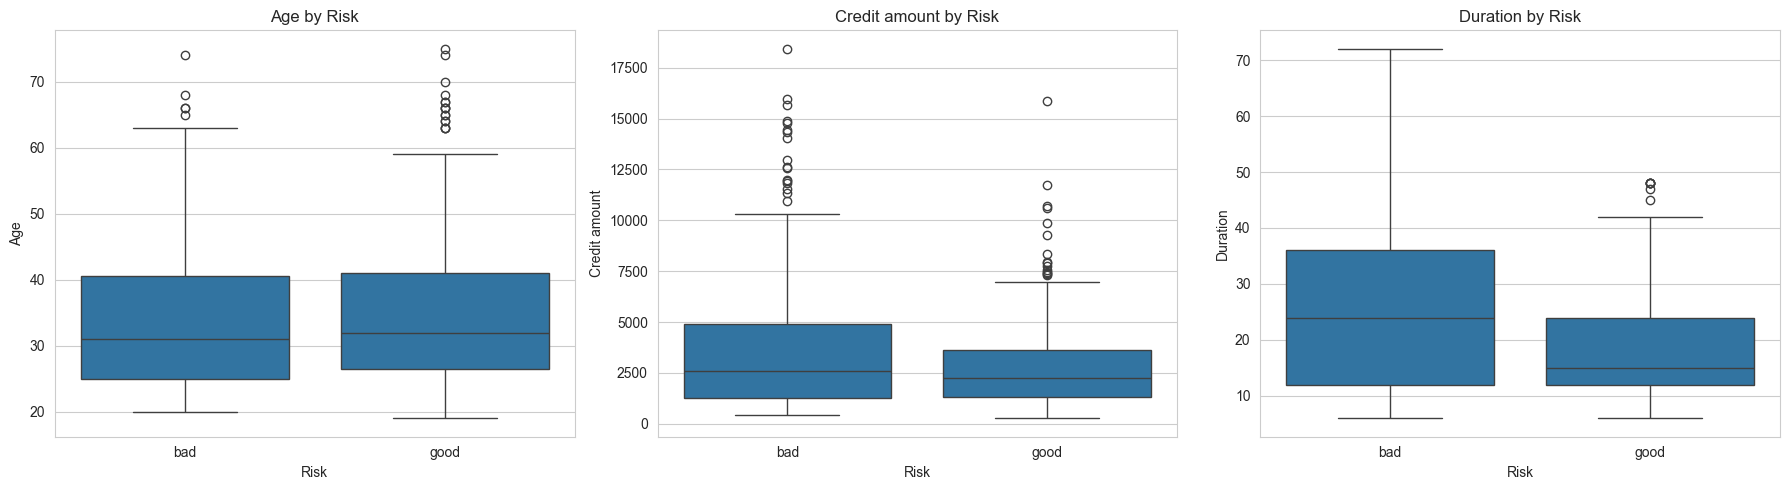

In [14]:
plt.figure(figsize=(18,5))

for i, col in enumerate(numerical_cols):

    plt.subplot(1,3,i+1)

    sns.boxplot(
        data=df,
        x="Risk",
        y=col
    )

    plt.title(f"{col} by Risk")

plt.tight_layout()

plt.show()

# Feature Selection

In [15]:
features = [
    "Age",
    "Sex",
    "Job",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Credit amount",
    "Duration"
]

target = "Risk"

df_model = df[features + [target]].copy()

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [16]:
categorical_features = df_model.select_dtypes(include="object").columns.tolist()

categorical_features.remove("Risk")

categorical_features

['Sex', 'Housing', 'Saving accounts', 'Checking account']

# Data Preprocessing

In [18]:
encoder_dict = {}

for col in categorical_features:

    le = LabelEncoder()

    df_model[col] = le.fit_transform(df_model[col])

    encoder_dict[col] = le

    joblib.dump(
        le,
        f"../models/{col.lower().replace(' ','_')}_encoder.pkl"
    )

print("Encoders Saved!")

Encoders Saved!


In [19]:
target_encoder = LabelEncoder()

df_model["Risk"] = target_encoder.fit_transform(df_model["Risk"])

joblib.dump(
    target_encoder,
    "../models/target_encoder.pkl"
)

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


# Model Training

## Data Preparation

In [20]:
X = df_model.drop("Risk", axis=1)
y = df_model["Risk"]

## Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=1
)

print(X_train.shape)
print(X_test.shape)

(417, 8)
(105, 8)


## Model Training Setup

In [22]:
def train_model(model, param_grid):

    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=5,
        scoring="accuracy",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    predictions = best_model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    return best_model, accuracy, grid.best_params_

In [23]:
dt_model = DecisionTreeClassifier(
    random_state=1,
    class_weight="balanced"
)

dt_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

best_dt, dt_acc, dt_best_params = train_model(
    dt_model,
    dt_params
)

print(dt_acc)
print(dt_best_params)

0.580952380952381
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [24]:
rf_model = RandomForestClassifier(
    random_state=1,
    class_weight="balanced",
    n_jobs=-1
)

rf_params = {
    "n_estimators":[100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

best_rf, rf_acc, rf_best_params = train_model(
    rf_model,
    rf_params
)

print(rf_acc)
print(rf_best_params)

0.6190476190476191
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [25]:
et_model = ExtraTreesClassifier(
    random_state=1,
    class_weight="balanced",
    n_jobs=-1
)

et_params = {
    "n_estimators":[100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

best_et, et_acc, et_best_params = train_model(
    et_model,
    et_params
)

print(et_acc)
print(et_best_params)

0.6476190476190476
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [26]:
xgb_model = XGBClassifier(
    random_state=1,
    scale_pos_weight=(
        (y_train == 0).sum() /
        (y_train == 1).sum()
    ),
    eval_metric="logloss"
)

xgb_params = {
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]
}

best_xgb, xgb_acc, xgb_best_params = train_model(
    xgb_model,
    xgb_params
)

print(xgb_acc)
print(xgb_best_params)

0.6761904761904762
{'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


# Model Comparison

In [27]:
results = pd.DataFrame({
    "Model":[
        "Decision Tree",
        "Random Forest",
        "Extra Trees",
        "XGBoost"
    ],
    "Accuracy":[
        dt_acc,
        rf_acc,
        et_acc,
        xgb_acc
    ]
})

results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
3,XGBoost,0.676190
2,Extra Trees,0.647619
1,Random Forest,0.619048
0,Decision Tree,0.580952


In [28]:
joblib.dump(
    best_xgb,
    "../models/xgboost_credit_model.pkl"
)

print("Model Saved!")

Model Saved!


# Model Evaluation

In [29]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [30]:
from sklearn.metrics import roc_auc_score

In [36]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
7,Duration,0.181387
4,Saving accounts,0.149530
1,Sex,0.122245
6,Credit amount,0.120813
5,Checking account,0.116545
2,Job,0.113816
0,Age,0.101851
3,Housing,0.093814


# Explainability with SHAP

## Calculating SHAP Values

In [37]:
import shap

explainer = shap.Explainer(best_xgb)

shap_values = explainer(X_test)

## Beeswarm Plot

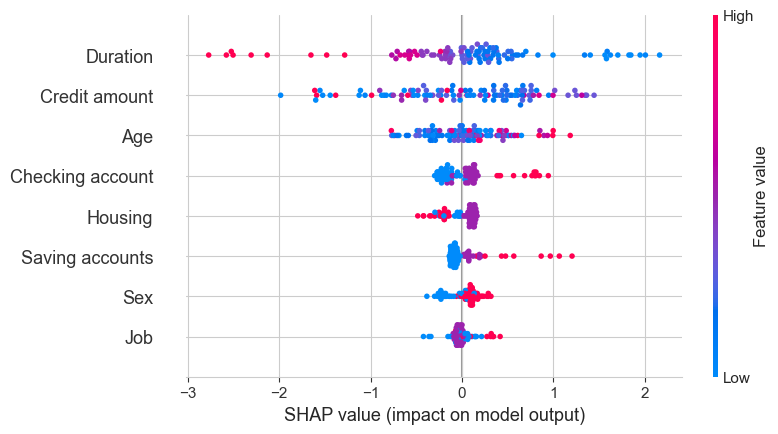

In [38]:
shap.plots.beeswarm(shap_values)

## Feature Importance Bar Plot

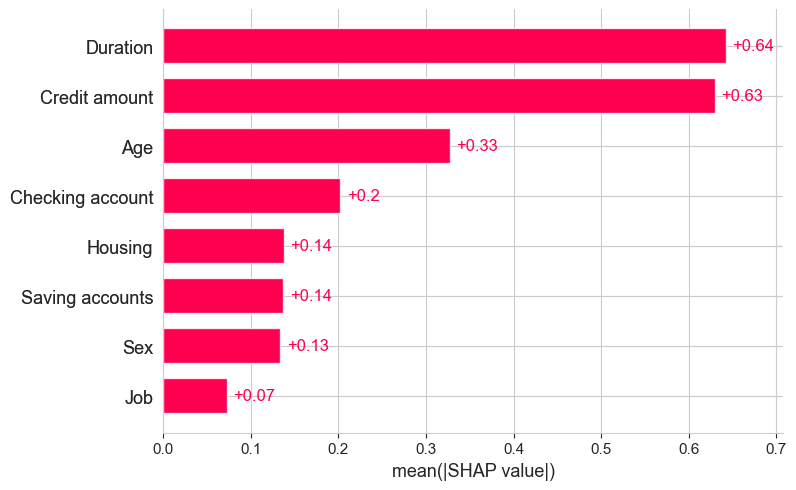

In [39]:
shap.plots.bar(shap_values)

## Waterfall Plot for Individual Prediction

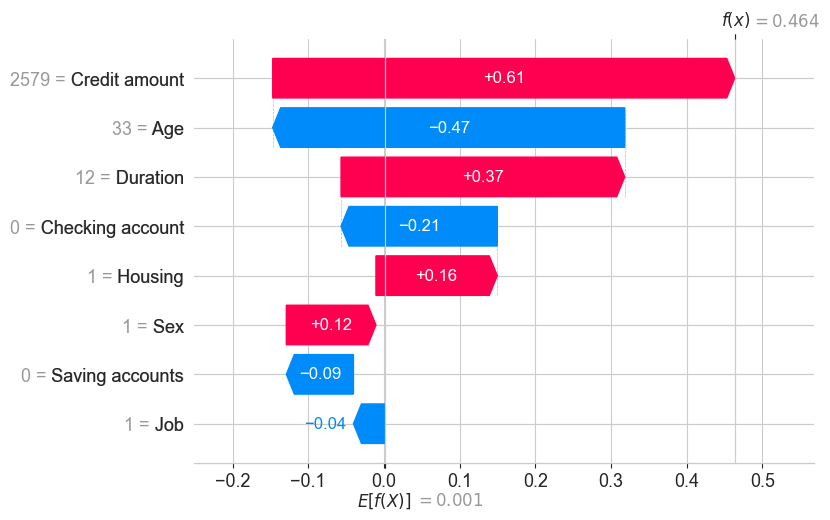

In [40]:
shap.plots.waterfall(shap_values[0])